### Checking if files suffered any transformation wrt single/dual tar gz

#### Number of files

In [ ]:
import os

# Define the directory path
dir_path = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/all_pcls_original'

# Check if the directory exists
if os.path.exists(dir_path):
    # Get the list of files in the directory
    file_count = len([f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))])
    print(f"Total number of .pcl files I used: {file_count}")
else:
    print(f"The directory {dir_path} does not exist.")


# Define the directory path
dir_path2 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted'

# Check if the directory exists
if os.path.exists(dir_path2):
    # Initialize a counter for the pcl files
    pcl_file_count = 0

    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path2):
        # Count .pcl files in each directory
        pcl_file_count += len([f for f in files if f.endswith('.pcl')])

    print(f"Total number of .pcl files in the single channel folders: {pcl_file_count}")
else:
    print(f"The directory {dir_path2} does not exist.")

# Define the directory path
dir_path3 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted'
# Check if the directory exists
if os.path.exists(dir_path3):
    # Initialize a counter for the pcl files
    pcl_file_count = 0

    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path3):
        # Count .pcl files in each directory
        pcl_file_count += len([f for f in files if f.endswith('.pcl')])

    print(f"Total number of .pcl files in the dual channel folders: {pcl_file_count}")
else:
    print(f"The directory {dir_path3} does not exist.")

# Define the directory path
dir_path4 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted'
# Check if the directory exists
if os.path.exists(dir_path4):
    # Initialize a counter for the pcl files
    pcl_file_count = 0

    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path4):
        # Count .pcl files in each directory
        pcl_file_count += len([f for f in files if f.endswith('.pcl')])

    print(f"Total number of .pcl files in all_spell_datasets: {pcl_file_count}")
else:
    print(f"The directory {dir_path4} does not exist.")

#### Duplicate files

In [ ]:
import os
from collections import defaultdict

# Define the directory path
dir_path4 = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_extracted'

# Dictionary to store pcl filenames and their occurrences
pcl_files = defaultdict(list)

# Check if the directory exists
if os.path.exists(dir_path4):
    # Walk through the directory and its subdirectories
    for root, dirs, files in os.walk(dir_path4):
        for f in files:
            if f.endswith('.pcl'):
                pcl_files[f].append(os.path.join(root, f))  # Store full path of each occurrence
else:
    print(f"The directory {dir_path4} does not exist.")

# Find duplicate files (files that appear more than once)
duplicates = {fname: paths for fname, paths in pcl_files.items() if len(paths) > 1}

# Print results
if duplicates:
    print(f"Found {len(duplicates)} duplicate .pcl filenames:")
    for fname, paths in duplicates.items():
        print(f"\nDuplicate: {fname}")
        for path in paths:
            print(f" - {path}")
else:
    print("No duplicate .pcl filenames found.")

#### Number of files in the intersections

In [ ]:
import os
from itertools import combinations

# Define the directory paths
directories = {
    "all_pcls_original": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/all_pcls_original",
    "single_channel_extracted": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_channel_extracted",
    "dual_channel_extracted": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted",
    "all_spell_extracted": "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted"
}

# Function to collect all .pcl filenames in a directory
def get_pcl_filenames(dir_path, nested=True):
    pcl_files = set()
    if os.path.exists(dir_path):
        if nested:  # If the directory contains subfolders
            for root, _, files in os.walk(dir_path):
                pcl_files.update({f for f in files if f.endswith('.pcl')})
        else:  # If the directory directly contains .pcl files
            pcl_files.update({f for f in os.listdir(dir_path) if f.endswith('.pcl')})
    return pcl_files

# Collect filenames from each directory
pcl_files_dict = {
    "all_pcls_original": get_pcl_filenames(directories["all_pcls_original"], nested=False),
    "single_channel_extracted": get_pcl_filenames(directories["single_channel_extracted"], nested=True),
    "dual_channel_extracted": get_pcl_filenames(directories["dual_channel_extracted"], nested=True),
    "all_spell_extracted": get_pcl_filenames(directories["all_spell_extracted"], nested=True),
}

# Compute pairwise intersections
for (name1, files1), (name2, files2) in combinations(pcl_files_dict.items(), 2):
    intersection = files1.intersection(files2)
    print(f"Intersection between {name1} and {name2}: {len(intersection)} common .pcl files")

# Total number of .pcl files all_original: 556
# Total number of .pcl files in the single channel folders: 336
# Total number of .pcl files in the dual channel folders: 448
# Total number of .pcl files in all_spell_datasets: 738


#### Missing/Matching

In [ ]:
import os
import filecmp

# Define the directory paths
single_dir = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/single_extracted'
all_dir = '/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted'

def get_pcl_files(dir_path):
    """
    Walk through the directory (including subdirectories) and return a dictionary
    mapping each .pcl filename to its full path (the first occurrence found).
    """
    pcl_files = {}
    for root, dirs, files in os.walk(dir_path):
        for f in files:
            if f.endswith('.pcl'):
                # If a file with this name hasn't been recorded, add it.
                if f not in pcl_files:
                    pcl_files[f] = os.path.join(root, f)
                # If there are duplicates within a folder, you can decide how to handle them.
    return pcl_files

# Get .pcl files from both directories
single_pcl = get_pcl_files(single_dir)
all_pcl = get_pcl_files(all_dir)

# Find missing files: those that are in the single channel folder but not in all_extracted
missing_files = set(single_pcl.keys()) - set(all_pcl.keys())
print(f"Number of missing .pcl files (in all_extracted): {len(missing_files)}")
if missing_files:
    print("Missing files:")
    for f in missing_files:
        print(f" - {f}")

# For common files, compare their contents using filecmp (deep comparison)
common_files = set(single_pcl.keys()).intersection(set(all_pcl.keys()))
identical_count = 0
for f in common_files:
    single_file_path = single_pcl[f]
    all_file_path = all_pcl[f]
    if filecmp.cmp(single_file_path, all_file_path, shallow=False):
        identical_count += 1

print(f"Number of common .pcl files with identical contents: {identical_count}")

### Negative Values

#### Overview

In [ ]:
import os
import pandas as pd

# Define the root directory where the subfolders are located
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/dual_channel_extracted"

total_columns = 0
columns_with_negatives = 0
columns_with_zero_negatives = 0
negative_counts = []

# Collect all pcl file paths
pcl_files = []

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith(".pcl"):
            pcl_files.append(os.path.join(root, file))

pcl_count = len(pcl_files)
print(f"Found {pcl_count} PCL files. Processing...")

# Process each PCL file
for file_path in pcl_files:
    try:
        df = pd.read_csv(file_path, sep="\t", index_col=0, header=0)

        # Convert all columns to numeric values, coercing errors to NaN
        df = df.apply(pd.to_numeric, errors='coerce')

        # Count total columns
        total_columns += df.shape[1]

        # Count columns that have at least one negative value
        negative_per_column = (df < 0).sum()

        # Count columns with at least 1 negative value
        columns_with_negatives += (negative_per_column > 0).sum()

        # Count columns with 0 negative values
        columns_with_zero_negatives += (negative_per_column == 0).sum()

        # Collect the negative counts for columns that contain at least 1 negative value
        negative_counts.extend(negative_per_column[negative_per_column > 0].values)

    except Exception as e:
        print(f"\nError reading {file_path}: {e}")

# Calculate the average negative values in columns that have at least 1 negative value
if columns_with_negatives > 0:
    average_negative_values = sum(negative_counts) / len(negative_counts)
else:
    average_negative_values = 0

# Final results
print("\nTotal number of columns across all PCL files:", total_columns)
print("Total number of columns with at least one negative value:", columns_with_negatives)
print("Total number of columns with zero negative values:", columns_with_zero_negatives)
print("Average number of negative values per column (for columns with at least 1 negative value):", average_negative_values)

### Checking expression distribution for a couple of genes

In [9]:
import pickle

with open('/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl', 'rb') as f:
    hk_genes = pickle.load(f)

print(hk_genes)

['YFL039C', 'YGR192C', 'YCR012W', 'YHR174W', 'YGR240C', 'YGL253W', 'YGL008C', 'YKL114C', 'YBR160W', 'YDR362C', 'YNL102W', 'YDR050C', 'YLR224W', 'YPL237W', 'YDR296W', 'YML099C', 'YBR118W', 'YDR224C', 'YBR010W', 'YPL151C', 'RDN18-1', 'RDN28-1', 'YDR261C', 'YGL195W', 'YDR155C', 'YHR085W']


Processing .pcl files: 100%|██████████| 779/779 [03:16<00:00,  3.97file/s]


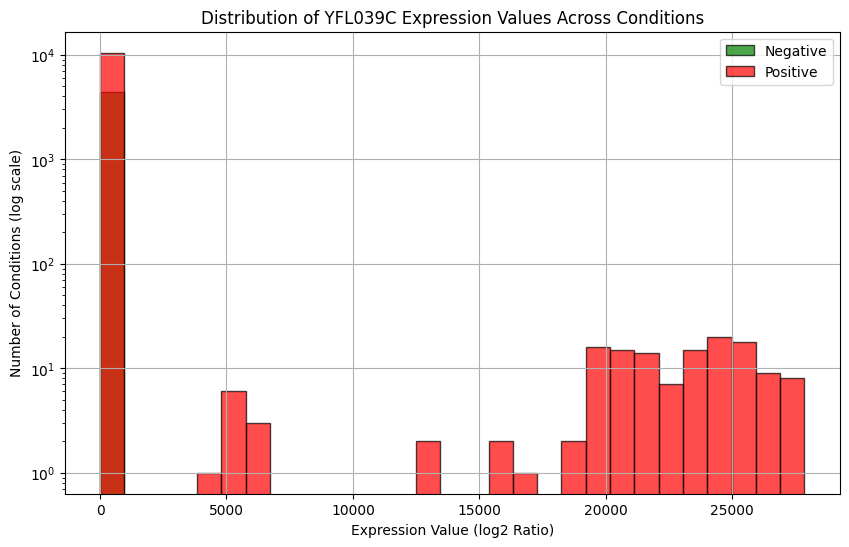

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Directory containing subfolders with .pcl files
root_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/data_inspection/all_spell_extracted"

# The gene of interest
gene = "YFL039C"

# Collect all .pcl file paths into a list
pcl_file_paths = []
for root, dirs, files in os.walk(root_dir):
    for filename in files:
        if filename.endswith(".pcl"):
            pcl_file_paths.append(os.path.join(root, filename))

# Container for expression values of the gene
all_expressions = []

# Loop through each .pcl file with a progress bar
for file_path in tqdm(pcl_file_paths, desc="Processing .pcl files", unit="file"):
    try:
        # Read the .pcl file; assuming tab-delimited with gene names as index
        df = pd.read_csv(file_path, sep="\t", index_col=0, header=0)
        # Convert all columns to numeric, coercing errors to NaN
        df = df.apply(pd.to_numeric, errors='coerce')
        # Check if the gene is present
        if gene in df.index:
            # Extract the row for the gene, drop NaNs, and add values to the list
            row_data = df.loc[gene].dropna()
            all_expressions.extend(row_data.values)
    except Exception as e:
        print(f"\nError reading {file_path}: {e}")


# # Split the data into negative and non-negative values
# negative_values = [val for val in all_expressions if val < 0]
# positive_values = [val for val in all_expressions if val >= 0]

# # Define bins (customize as needed; here we use 30 bins spanning the data range)
# bins = np.linspace(min(all_expressions), max(all_expressions), 30)

# # Create the histogram
# plt.figure(figsize=(10, 6))
# # Plot negative values in green
# plt.hist(negative_values, bins=bins, color='green', edgecolor='black', alpha=0.7, label="Negative")
# # Plot positive (and zero) values in red
# plt.hist(positive_values, bins=bins, color='red', edgecolor='black', alpha=0.7, label="Positive")

# # Set y-axis to logarithmic scale
# plt.yscale('log')
# plt.xlabel("Expression Value (log2 Ratio)")
# plt.ylabel("Number of Conditions (log scale)")
# plt.title(f"Distribution of {gene} Expression Values Across Conditions")
# plt.legend()
# plt.grid(True)
# plt.show()